# **UCI-HAR - Depthwise (PyTorch)**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# PyTorch 관련 라이브러리 임포트
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [ ]:
# GPU 가속 공식 설정 (Colab 환경 대응)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Data load

In [ ]:
TRAIN = "train/"
TEST = "test/"

# 구글 드라이브 연동 경로 유지
DATASET_PATH = "/content/drive/MyDrive/AI_Study/UCI_HAR_Dataset/"

In [ ]:
# UCI HAR 데이터셋 상수 설정
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

In [ ]:
# 1. X 데이터 로드 함수 수정 (파이토치 1D CNN 차원에 맞춤)
def load_X(X_signals_paths):
    X_signals = []

    for signal_type_path in X_signals_paths:
        series_list = []

        with open(signal_type_path, 'r') as file:
            for row in file:
                row_clean = row.replace('  ', ' ')
                row_clean = row_clean.strip()
                serie = row_clean.split(' ')
                serie_array = np.array(serie, dtype=np.float32)
                series_list.append(serie_array)

        X_signals.append(series_list)

    # shape: (특성 수, 샘플 수, 타임스텝 수)
    X_signals = np.array(X_signals)

    # [기존] 텐서플로우용: (1, 2, 0) -> (샘플 수, 타임스텝 수, 특성 수)
    # [수정] 파이토치용:   (1, 0, 2) -> (샘플 수, 특성 수, 타임스텝 수)
    # 파이토치 nn.Conv1d는 채널(특성 수)이 중간에 와야 한다.
    return np.transpose(X_signals, (1, 0, 2))


X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial_Signals/" + signal + "train.txt"
    for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial_Signals/" + signal + "test.txt"
    for signal in INPUT_SIGNAL_TYPES
]

X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)

print("=== X Data Shape (PyTorch Style) ===")
print("X_train shape (Batch, Channels, Timesteps):", X_train.shape) # (7352, 9, 128)
print("X_test shape (Batch, Channels, Timesteps):", X_test.shape)   # (2947, 9, 128)

=== X Data Shape (PyTorch Style) ===
X_train shape (Batch, Channels, Timesteps): (7352, 9, 128)
X_test shape (Batch, Channels, Timesteps): (2947, 9, 128)


In [ ]:
# 2. y 데이터 로드 함수 (정수형 레이블 그대로 유지)
def load_y(y_path):
    with open(y_path, 'r') as file:
        labels = [int(line.strip()) for line in file]
    # 파이토치 CrossEntropyLoss는 target으로 Long(int64) 타입을 요구하므로 np.int64로 설정
    return np.array(labels, dtype=np.int64) - 1


y_train_path = DATASET_PATH + TRAIN + "y_train.txt"
y_test_path = DATASET_PATH + TEST + "y_test.txt"

y_train = load_y(y_train_path)
y_test = load_y(y_test_path)

print("\n=== y Data Shape ===")
print("y_train shape (정수 인덱스):", y_train.shape) # (7352,)
print("y_test shape (정수 인덱스):", y_test.shape)   # (2947,)
print("y_train 앞 5개 샘플:", y_train[:5])


=== y Data Shape ===
y_train shape (정수 인덱스): (7352,)
y_test shape (정수 인덱스): (2947,)
y_train 앞 5개 샘플: [4 4 4 4 4]


# Model building

Depthwise Separable Conv 블록 정의

In [ ]:
class DepthwiseSeparableConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding):
        super(DepthwiseSeparableConv1d, self).__init__()

        # 1. Depthwise Convolution: 각 채널마다 독립적으로 필터 적용 (groups = 입력 채널수)
        self.depthwise = nn.Conv1d(
            in_channels=in_channels,
            out_channels=in_channels,
            kernel_size=kernel_size,
            padding=padding,
            groups=in_channels
        )

        # 2. Pointwise Convolution: 1x1 Conv를 통해 채널 간 정보 융합 및 차원(채널) 변경
        self.pointwise = nn.Conv1d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=1
        )

    def forward(self, x):
        out = self.depthwise(x)
        out = self.pointwise(out)
        return out

전체 모델 빌딩

In [ ]:
class DepthwiseNet1D(nn.Module):
    def __init__(self, in_channels=9, num_classes=6):
        super(DepthwiseNet1D, self).__init__()

        # 첫 번째 특징 추출
        self.block1 = nn.Sequential(
            DepthwiseSeparableConv1d(in_channels, 128, kernel_size=7, padding=3),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )

        # 두 번째 특징 추출 (+ MaxPooling, Dropout)
        self.block2 = nn.Sequential(
            DepthwiseSeparableConv1d(128, 256, kernel_size=5, padding=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.3)
        )

        # 세 번째 특징 추출
        self.block3 = nn.Sequential(
            DepthwiseSeparableConv1d(256, 256, kernel_size=5, padding=2),
            nn.BatchNorm1d(256),
            nn.ReLU()
        )

        # 네 번째 특징 추출 (+ MaxPooling)
        self.block4 = nn.Sequential(
            DepthwiseSeparableConv1d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        # 차원 축소 및 분류층
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Sequential(
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        # Global Average Pooling 후 평탄화
        x = self.global_pool(x).squeeze(-1)

        # Fully Connected Layer
        output = self.fc(x)
        return output

# 모델 생성 및 구조 확인
model = DepthwiseNet1D(in_channels=9, num_classes=6).to(device)
print(model)

DepthwiseNet1D(
  (block1): Sequential(
    (0): DepthwiseSeparableConv1d(
      (depthwise): Conv1d(9, 9, kernel_size=(7,), stride=(1,), padding=(3,), groups=9)
      (pointwise): Conv1d(9, 128, kernel_size=(1,), stride=(1,))
    )
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (block2): Sequential(
    (0): DepthwiseSeparableConv1d(
      (depthwise): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), groups=128)
      (pointwise): Conv1d(128, 256, kernel_size=(1,), stride=(1,))
    )
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.3, inplace=False)
  )
  (block3): Sequential(
    (0): DepthwiseSeparableConv1d(
      (depthwise): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=(2,), groups=256)
      (pointwise): Conv1d(256, 256, kernel_size

# Loss + Callback

In [ ]:
import copy
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

# 손실함수 및 옵티마이저 정의
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ReduceLROnPlateau 스케줄러 정의
lr_scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.2,
    patience=8,
    min_lr=0.00001
)

# ModelCheckpoint 및 EarlyStopping 정의
early_stopping_patience = 25
patience_counter = 0

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

checkpoint_path = "UCI_HAR_Depthwise_best.pt"

# Model train

In [ ]:
import time
from torch.utils.data import TensorDataset, random_split

# --- 1. Dataset 및 DataLoader 준비 (Keras의 validation_split=0.2 및 batch_size=16 대응) ---
# 넘파이 배열을 파이토치 텐서로 변환
X_tensor = torch.tensor(X_train, dtype=torch.float32)
y_tensor = torch.tensor(y_train, dtype=torch.long)  # 원-핫 인코딩 대신 정수형 레이블 사용

# 전체 데이터셋 생성
full_dataset = TensorDataset(X_tensor, y_tensor)

# 80% 학습, 20% 검증 데이터로 분할
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# DataLoader 생성 (batch_size=16)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [ ]:
# --- 2. History 저장을 위한 딕셔너리 정의 ---
history = {
    'loss': [],
    'accuracy': [],
    'val_loss': [],
    'val_accuracy': []
}

In [ ]:
# --- 3. 학습 및 검증 루프 실행 (epochs=100) ---
epochs = 100

for epoch in range(1, epochs + 1):
    start_time = time.time()

    # [Train Phase]
    model.train()
    train_loss = 0.0
    train_correct = 0
    total_train_samples = 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # 그래디언트 초기화
        optimizer.zero_grad()

        # 순전파 (Forward)
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        # 역전파 및 가중치 업데이트 (Backward)
        loss.backward()
        optimizer.step()

        # 통계 계산
        train_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == batch_y).sum().item()
        total_train_samples += batch_X.size(0)

    epoch_train_loss = train_loss / total_train_samples
    epoch_train_acc = train_correct / total_train_samples

    # [Validation Phase]
    model.eval()
    val_loss = 0.0
    val_correct = 0
    total_val_samples = 0

    with torch.no_grad(): # 검증 시에는 그래디언트 계산 제외 (메모리 절약)
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            val_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == batch_y).sum().item()
            total_val_samples += batch_X.size(0)

    epoch_val_loss = val_loss / total_val_samples
    epoch_val_acc = val_correct / total_val_samples

    # History 기록
    history['loss'].append(epoch_train_loss)
    history['accuracy'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc)

    # 에폭 결과 출력 (Keras의 verbose=1 스타일)
    epoch_time = time.time() - start_time
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch}/{epochs} - {epoch_time:.1f}s - loss: {epoch_train_loss:.4f} - accuracy: {epoch_train_acc:.4f} - val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f} - lr: {current_lr:.6f}")

    # --- 4. Callbacks 수동 연동 단계 ---
    # (1) ReduceLROnPlateau 스케줄러 업데이트
    lr_scheduler.step(epoch_val_loss)

    # (2) ModelCheckpoint & EarlyStopping 체크
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_model_wts = copy.deepcopy(model.state_dict()) # 최적 가중치 메모리 복사
        torch.save(model.state_dict(), checkpoint_path)    # 파일 저장 (.pt)
        print(f"Epoch {epoch}: val_categorical_accuracy improved to {epoch_val_acc:.5f}, saving model to {checkpoint_path}")
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= early_stopping_patience:
        print(f"Early stopping triggered. Restoring model weights from the end of the best epoch.")
        model.load_state_dict(best_model_wts) # 최적 가중치로 복원
        break

Epoch 1/100 - 3.7s - loss: 0.3584 - accuracy: 0.8679 - val_loss: 0.1521 - val_accuracy: 0.9449 - lr: 0.001000
Epoch 1: val_categorical_accuracy improved to 0.94494, saving model to UCI_HAR_Depthwise_best.pt
Epoch 2/100 - 2.2s - loss: 0.1932 - accuracy: 0.9272 - val_loss: 0.1218 - val_accuracy: 0.9511 - lr: 0.001000
Epoch 2: val_categorical_accuracy improved to 0.95105, saving model to UCI_HAR_Depthwise_best.pt
Epoch 3/100 - 1.8s - loss: 0.1550 - accuracy: 0.9395 - val_loss: 0.1209 - val_accuracy: 0.9490 - lr: 0.001000
Epoch 4/100 - 1.8s - loss: 0.1553 - accuracy: 0.9356 - val_loss: 0.1148 - val_accuracy: 0.9531 - lr: 0.001000
Epoch 4: val_categorical_accuracy improved to 0.95309, saving model to UCI_HAR_Depthwise_best.pt
Epoch 5/100 - 1.8s - loss: 0.1523 - accuracy: 0.9374 - val_loss: 0.1190 - val_accuracy: 0.9545 - lr: 0.001000
Epoch 5: val_categorical_accuracy improved to 0.95445, saving model to UCI_HAR_Depthwise_best.pt
Epoch 6/100 - 1.8s - loss: 0.1459 - accuracy: 0.9429 - val_los

# Evaluation

Best 기록 확인

In [ ]:
# --- 1. 가중치를 불러올 빈 모델 객체 생성 ---
best_model = DepthwiseNet1D(in_channels=9, num_classes=6).to(device)

# 가중치 파일(.pt) 로드
best_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
print(f"Successfully loaded best model weights from {checkpoint_path}")


# --- 2. 데이터 평가를 위한 수동 함수 정의 ---
def evaluate_pytorch_model(model, X_data, y_data, batch_size=16):
    # 케라스의 evaluate(verbose=0)처럼 배치를 돌며 손실과 정확도를 누적 계산
    model.eval() # 평가 모드 활성화 (Dropout, BatchNorm 동결)

    # 평가용 DataLoader 구성
    eval_tensor_X = torch.tensor(X_data, dtype=torch.float32)
    eval_tensor_y = torch.tensor(y_data, dtype=torch.long)
    eval_dataset = TensorDataset(eval_tensor_X, eval_tensor_y)
    eval_loader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False)

    total_loss = 0.0
    correct = 0
    total_samples = 0

    with torch.no_grad(): # 평가 단계이므로 그래디언트 계산 제외
        for batch_X, batch_y in eval_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            total_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == batch_y).sum().item()
            total_samples += batch_X.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = correct / total_samples
    return avg_loss, avg_acc


# --- 3. Training & Test 데이터셋 평가 및 출력 ---
# X_train전체 데이터에 대해 평가 (Keras의 validation_split 전 원본 데이터 기준)
train_loss, train_acc = evaluate_pytorch_model(best_model, X_train, y_train)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

# X_test 데이터셋 평가
test_loss, test_acc = evaluate_pytorch_model(best_model, X_test, y_test)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Successfully loaded best model weights from UCI_HAR_Depthwise_best.pt
Training accuracy: 99.77%
Training loss: 0.0093
Test accuracy: 95.69%
Test loss: 0.1440


Classification Report

In [ ]:
import torch.nn.functional as F

# --- 1. 모델 예측 (Keras의 model.predict 부분) ---
best_model.eval() # 평가 모드 활성화

# 예측용 DataLoader 구성 (X_test 전체를 안정적으로 처리하기 위해 배치 단위 구동)
test_tensor_X = torch.tensor(X_test, dtype=torch.float32)
test_dataset = TensorDataset(test_tensor_X)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

y_pred_list = []

with torch.no_grad():
    for batch_X in test_loader:
        batch_X = batch_X[0].to(device) # TensorDataset은 튜플 형태로 반환하므로 꺼내옴

        # 순전파로 로짓(Logit) 계산
        outputs = best_model(batch_X)

        # 로짓을 소프트맥스를 통해 확률값(0~1 사이)으로 변환 (Keras의 predict 결과와 대응되는 부분)
        probabilities = F.softmax(outputs, dim=1)

        # 가장 높은 확률을 가진 클래스 추출
        _, predicted = torch.max(probabilities, 1)

        # CPU로 넘긴 뒤 리스트에 저장
        y_pred_list.extend(predicted.cpu().numpy())

# 넘파이 배열로 최종 변환
y_pred = np.array(y_pred_list)


# --- 2. 분류 리포트 출력 ---
print("\nClassification Report:")
# y_test는 이미 정수형 레이블(0~5)이므로 그대로 사용
print(classification_report(y_test, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     1.0000    0.9980    0.9990       496
           1     0.9977    0.9406    0.9683       471
           2     0.9476    0.9905    0.9686       420
           3     0.9453    0.8452    0.8925       491
           4     0.8756    0.9662    0.9187       532
           5     0.9890    1.0000    0.9944       537

    accuracy                         0.9569      2947
   macro avg     0.9592    0.9567    0.9569      2947
weighted avg     0.9586    0.9569    0.9567      2947



Loss / Accuracy 그래프

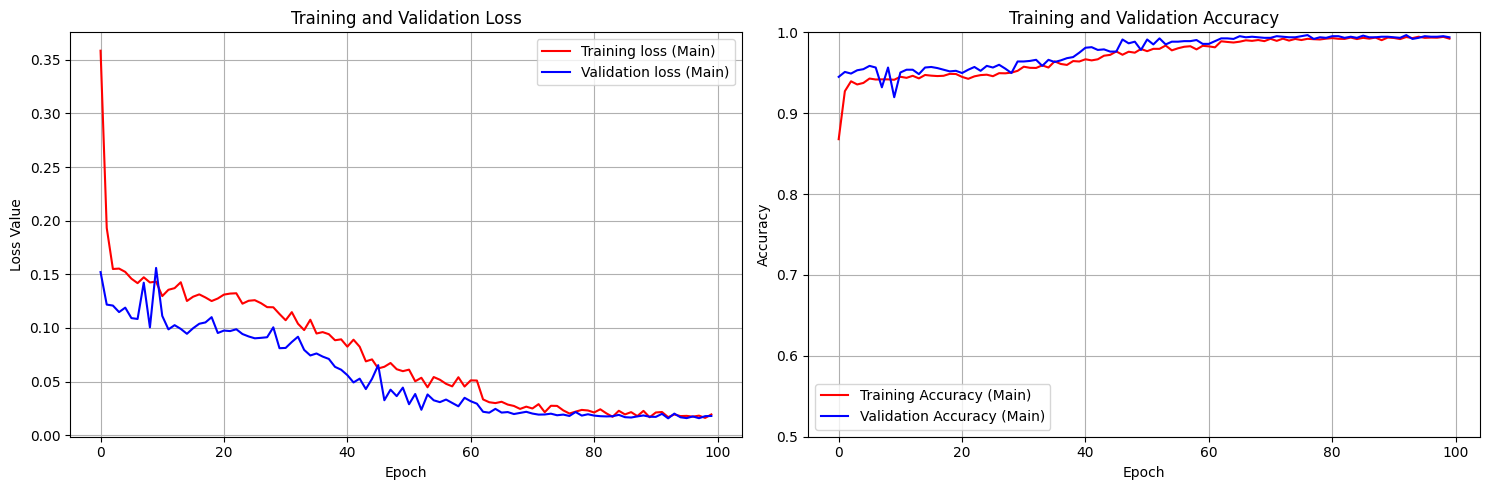

In [ ]:
# --- 1. History 딕셔너리에서 학습 기록 데이터 추출 ---
# 파이토치 루프에서 직접 채워넣은 history 딕셔너리를 활용
train_loss = history['loss']
train_accuracy = history['accuracy']
val_loss = history['val_loss']
val_accuracy = history['val_accuracy']

# --- 2. Matplotlib을 이용한 시각화 그래프 그리기 ---
plt.figure(figsize=(15, 5))

# 2-1. Loss 그래프 (왼쪽)
plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss (Main)')
plt.plot(val_loss, 'b', label='Validation loss (Main)')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

# 2-2. Accuracy 그래프 (오른쪽)
plt.subplot(1, 2, 2)
plt.ylim([0.5, 1.0]) # 데이터셋 특성에 맞춰 Y축 범위 지정
plt.plot(train_accuracy, 'r', label='Training Accuracy (Main)')
plt.plot(val_accuracy, 'b', label='Validation Accuracy (Main)')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

혼동 행렬 (Confusion Matrix)

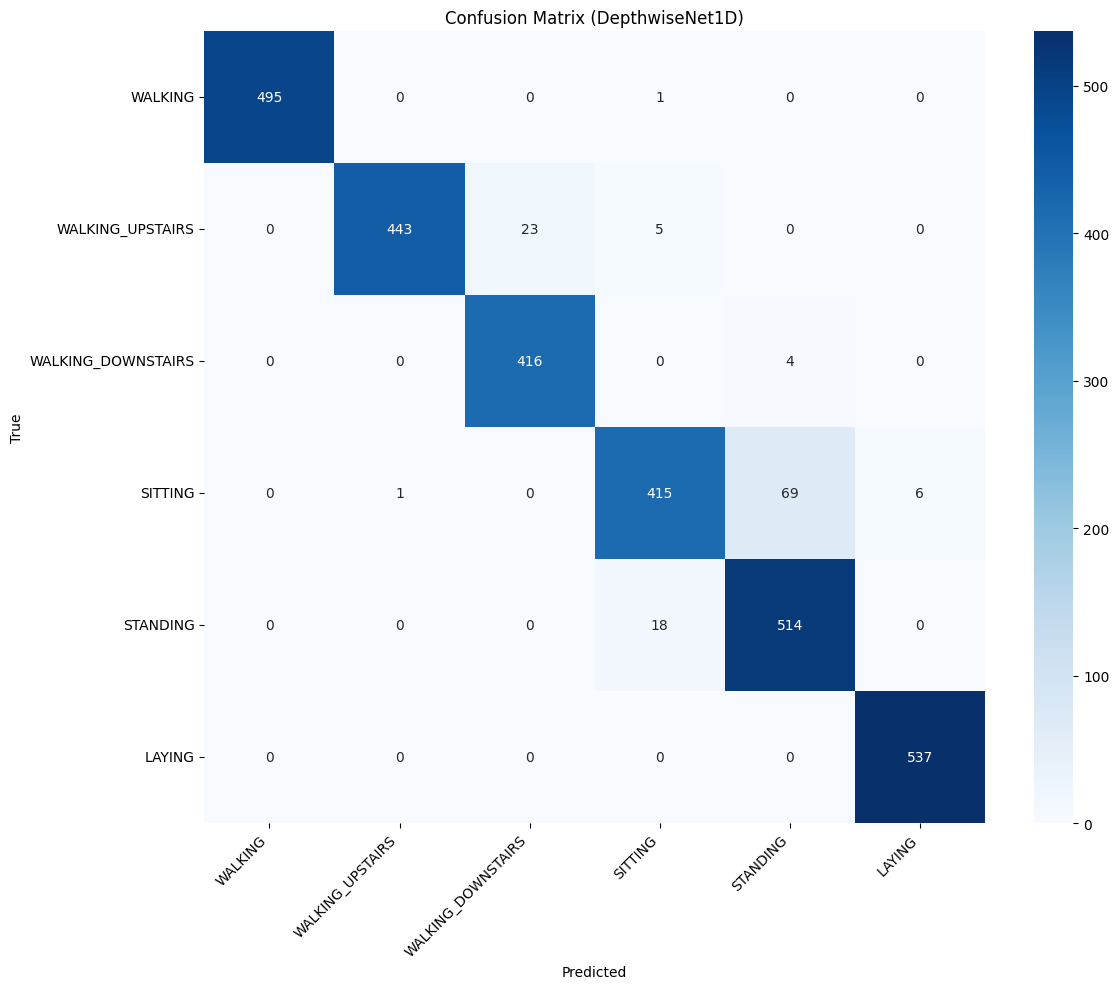

In [ ]:
# --- 1. 혼동 행렬(Confusion Matrix) 계산 ---
cm = confusion_matrix(y_test, y_pred)

# --- 2. Seaborn Heatmap을 이용한 시각화 ---
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (DepthwiseNet1D)')

# 클래스 개수에 맞게 축 레이블(WALKING, SITTING 등) 설정
n_classes = len(np.unique(y_test))
if n_classes <= len(LABELS):
    plt.gca().set_xticklabels(LABELS[:n_classes], rotation=45, ha='right')
    plt.gca().set_yticklabels(LABELS[:n_classes], rotation=0)

plt.tight_layout()
plt.show()